In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import contextily as ctx
import utils

from matplotlib.patches import Rectangle
from matplotlib.colors import PowerNorm, TwoSlopeNorm, LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [2]:
def add_safe_basemap(ax, source=None, attribution=False):
    """Add basemap tiles when available; keep plotting if the tile server fails."""
    if source is None:
        source = ctx.providers.CartoDB.PositronNoLabels
    try:
        ctx.add_basemap(ax, source=source, attribution=attribution)
        return True
    except Exception as exc:
        print(f"Basemap skipped: {type(exc).__name__}: {exc}")
        return False


In [3]:
def load_aimsun(plan_name, rep=-1):
    df = pd.read_parquet(f"../data/processed/{plan_name}_aimsun.parquet")
    return df[df["rep"] == rep].copy()


def _line_endpoints(geom):
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
        return np.array(coords[0]), np.array(coords[-1])
    elif geom.geom_type == "MultiLineString":
        first = list(geom.geoms[0].coords)
        last = list(geom.geoms[-1].coords)
        return np.array(first[0]), np.array(last[-1])
    else:
        return None, None


def _endpoint_match_score(a1, a2, b1, b2):
    s1 = np.linalg.norm(a1 - b1) + np.linalg.norm(a2 - b2)
    s2 = np.linalg.norm(a1 - b2) + np.linalg.norm(a2 - b1)
    return min(s1, s2)


_SECTION_GDF_CACHE = None


def get_section_geometries_cached():
    global _SECTION_GDF_CACHE

    if _SECTION_GDF_CACHE is not None:
        return _SECTION_GDF_CACHE.copy()

    roads = gpd.read_file("../data/external/aimsun_topo/section_edit.shp")

    if roads.crs is None:
        raise ValueError("section_edit.shp has no CRS.")

    load = utils.LoadData()
    G_primal, _ = load.load_map_data(
        "../data/external/aimsun_topo/section_edit.shp",
        "../data/external/aimsun_topo/nodes.shp"
    )

    shp = roads.copy()
    shp["_p1"], shp["_p2"] = zip(*shp.geometry.apply(_line_endpoints))
    valid = shp[shp["_p1"].notna()].copy()

    rows = []

    for u, v, k, e in G_primal.edges(data=True, keys=True):
        oid = e.get("name")

        x1, y1 = G_primal.nodes[u]["loc"].x, G_primal.nodes[u]["loc"].y
        x2, y2 = G_primal.nodes[v]["loc"].x, G_primal.nodes[v]["loc"].y

        p1 = np.array([x1, y1])
        p2 = np.array([x2, y2])

        valid["_score"] = valid.apply(
            lambda r: _endpoint_match_score(p1, p2, r["_p1"], r["_p2"]),
            axis=1
        )

        best = valid.sort_values("_score").iloc[0]

        rows.append({
            "oid": str(oid),
            "geometry": best.geometry
        })

    _SECTION_GDF_CACHE = gpd.GeoDataFrame(rows, geometry="geometry", crs=roads.crs)
    return _SECTION_GDF_CACHE.copy()


def make_bbox_from_frac(xmin, ymin, xmax, ymax, x0, x1, y0, y1):
    dx = xmax - xmin
    dy = ymax - ymin
    return (
        xmin + x0 * dx,
        xmin + x1 * dx,
        ymin + y0 * dy,
        ymin + y1 * dy,
    )


def get_core_region_bboxes():
    roads = get_section_geometries_cached().to_crs(epsg=3857)
    xmin, ymin, xmax, ymax = roads.total_bounds

    # Region 1: downtown
    region1 = make_bbox_from_frac(
        xmin, ymin, xmax, ymax,
        x0=0.65, x1=0.95,
        y0=0.75, y1=0.93
    )

    # Region 2: southwest
    region2 = make_bbox_from_frac(
        xmin, ymin, xmax, ymax,
        x0=0.55, x1=0.85,
        y0=0.48, y1=0.66
    )

    return {
        "Region 1": region1,
        "Region 2": region2,
    }


def get_shared_vmin_vmax(plan_names, ent, metric_col, scale=1.0, q_low=2, q_high=98):
    vals = []

    for plan in plan_names:
        total = load_aimsun(plan, rep=-1)
        total_ent = total[total["ent"] == ent]
        vals.append(total_ent[metric_col].to_numpy() * scale)

    vals = np.concatenate(vals)
    vals = vals[np.isfinite(vals)]

    vmin = np.nanpercentile(vals, q_low)
    vmax = np.nanpercentile(vals, q_high)

    if np.isclose(vmin, vmax):
        vmin = np.nanmin(vals)
        vmax = np.nanmax(vals)

    return vmin, vmax


def get_metric_gdf(total, ent, metric_col, scale):
    roads = get_section_geometries_cached()

    total_ent = total[total["ent"] == ent].copy()
    total_ent["oid"] = total_ent["oid"].astype(str)
    total_ent["plot_value"] = total_ent[metric_col] * scale

    gdf = roads.merge(
        total_ent[["oid", "plot_value"]],
        on="oid",
        how="left"
    ).to_crs(epsg=3857)

    return gdf


In [4]:
def set_bbox_with_fixed_aspect(ax, bbox, target_aspect=0.72):
    """
    target_aspect = height / width
    smaller -> wider panel
    """

    xmin, xmax, ymin, ymax = bbox

    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2

    width = xmax - xmin
    height = ymax - ymin

    current_aspect = height / width

    if current_aspect > target_aspect:
        new_width = height / target_aspect
        new_height = height
    else:
        new_width = width
        new_height = width * target_aspect

    ax.set_xlim(
        cx - new_width / 2,
        cx + new_width / 2
    )

    ax.set_ylim(
        cy - new_height / 2,
        cy + new_height / 2
    )


def get_diff_gdf(
    method_plan,
    ent,
    metric_col,
    scale=1.0,
    baseline_plan="Fix",
    direction="method_minus_fix",
):
    """
    Build a road GeoDataFrame with method-vs-Fix differences.

    direction="method_minus_fix" gives method - Fix, used for speed.
    direction="fix_minus_method" gives Fix - method, used for CO2 reduction.
    """
    roads = get_section_geometries_cached()

    method = load_aimsun(method_plan, rep=-1)
    baseline = load_aimsun(baseline_plan, rep=-1)

    method_ent = method[method["ent"] == ent].copy()
    baseline_ent = baseline[baseline["ent"] == ent].copy()

    method_ent["oid"] = method_ent["oid"].astype(str)
    baseline_ent["oid"] = baseline_ent["oid"].astype(str)

    merged = baseline_ent[["oid", metric_col]].rename(
        columns={metric_col: "baseline_value"}
    ).merge(
        method_ent[["oid", metric_col]].rename(
            columns={metric_col: "method_value"}
        ),
        on="oid",
        how="outer"
    )

    if direction == "method_minus_fix":
        merged["plot_value"] = (
            merged["method_value"] - merged["baseline_value"]
        ) * scale
    elif direction == "fix_minus_method":
        merged["plot_value"] = (
            merged["baseline_value"] - merged["method_value"]
        ) * scale
    else:
        raise ValueError(
            "direction must be 'method_minus_fix' or 'fix_minus_method'."
        )

    gdf = roads.merge(
        merged[["oid", "plot_value"]],
        on="oid",
        how="left"
    ).to_crs(epsg=3857)

    return gdf


def _region_mask(gdf, bbox):
    xmin, xmax, ymin, ymax = bbox
    centroids = gdf.geometry.centroid
    return (
        (centroids.x >= xmin) & (centroids.x <= xmax) &
        (centroids.y >= ymin) & (centroids.y <= ymax)
    )


def get_shared_diff_range(
    method_plans,
    region_names,
    ent_by_region,
    metric_col,
    scale=1.0,
    direction="method_minus_fix",
    q=92,
):
    vals = []
    region_bboxes = get_core_region_bboxes()

    for region_name in region_names:
        bbox = region_bboxes[region_name]
        ent = ent_by_region[region_name]

        for method_plan in method_plans:
            gdf = get_diff_gdf(
                method_plan=method_plan,
                ent=ent,
                metric_col=metric_col,
                scale=scale,
                direction=direction,
            )

            in_region = _region_mask(gdf, bbox)
            vals.append(gdf.loc[in_region, "plot_value"].to_numpy())

    vals = np.concatenate(vals)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        raise ValueError("No finite difference values found for shared range.")

    vmax = np.nanpercentile(np.abs(vals), q)

    if np.isclose(vmax, 0):
        vmax = np.nanmax(np.abs(vals))

    if np.isclose(vmax, 0):
        vmax = 1.0

    return -vmax, vmax


def get_soft_diverging_cmap(metric):
    """High-contrast publication palettes: speed uses orange-to-teal; CO2 uses teal-to-orange."""
    if metric == "speed":
        # negative = slower than Fix; positive = faster than Fix
        return LinearSegmentedColormap.from_list(
            "speed_orange_teal_contrast",
            [
                (0.00, "#b53a12"),
                (0.22, "#f46d2d"),
                (0.46, "#f7c6aa"),
                (0.54, "#bfe8dd"),
                (0.78, "#00a88f"),
                (1.00, "#005f4f"),
            ]
        )

    if metric == "co2":
        # negative = CO2 reduction; positive = CO2 increase
        return LinearSegmentedColormap.from_list(
            "co2_teal_orange_contrast",
            [
                (0.00, "#005f4f"),
                (0.22, "#00a88f"),
                (0.46, "#bfe8dd"),
                (0.54, "#f7c6aa"),
                (0.78, "#f46d2d"),
                (1.00, "#b53a12"),
            ]
        )

    raise ValueError("metric must be 'speed' or 'co2'.")


In [5]:
def build_rep_ts(
    df,
    metric_col,
    scale=1.0,
    ent_step=3,
    normalize=True
):
    data = df.copy()

    data = data[data[metric_col].notna()].copy()

    data["value"] = data[metric_col] * scale

    if ent_step is not None:
        data = data[data["ent"] % ent_step == 0]

    rep_ts = (
        data.groupby(["rep", "ent"])["value"]
            .mean()
            .reset_index()
    )

    if normalize:
        ymin = rep_ts["value"].min()
        ymax = rep_ts["value"].max()

        if not np.isclose(ymin, ymax):
            rep_ts["value_norm"] = (
                rep_ts["value"] - ymin
            ) / (ymax - ymin)
        else:
            rep_ts["value_norm"] = 0.0

    else:
        rep_ts["value_norm"] = rep_ts["value"]

    rep_ts["time"] = rep_ts["ent"].apply(
        lambda e:
        pd.Timestamp("2022-01-01 06:00:00")
        + pd.Timedelta(minutes=int(e))
    )

    return rep_ts


In [6]:
traffic_metrics = {
    "Speed": {
        "col": "speed",
        "scale": 1.0
    },

    "Travel time": {
        "col": "ttime",
        "scale": 1.0
    },

    "Flow": {
        "col": "flow",
        "scale": 1.0
    },

    "Density": {
        "col": "density",
        "scale": 1.0
    },
}


emission_metrics = {
    "CO$_2$": {
        "col": "CO2_interurban",
        "scale": 1 / 1000
    },

    "NO$_x$": {
        "col": "NOx_interurban",
        "scale": 1.0
    },

    "VOC": {
        "col": "VOC_interurban",
        "scale": 1.0
    },

    "PM": {
        "col": "PM_interurban",
        "scale": 1.0
    },
}


1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


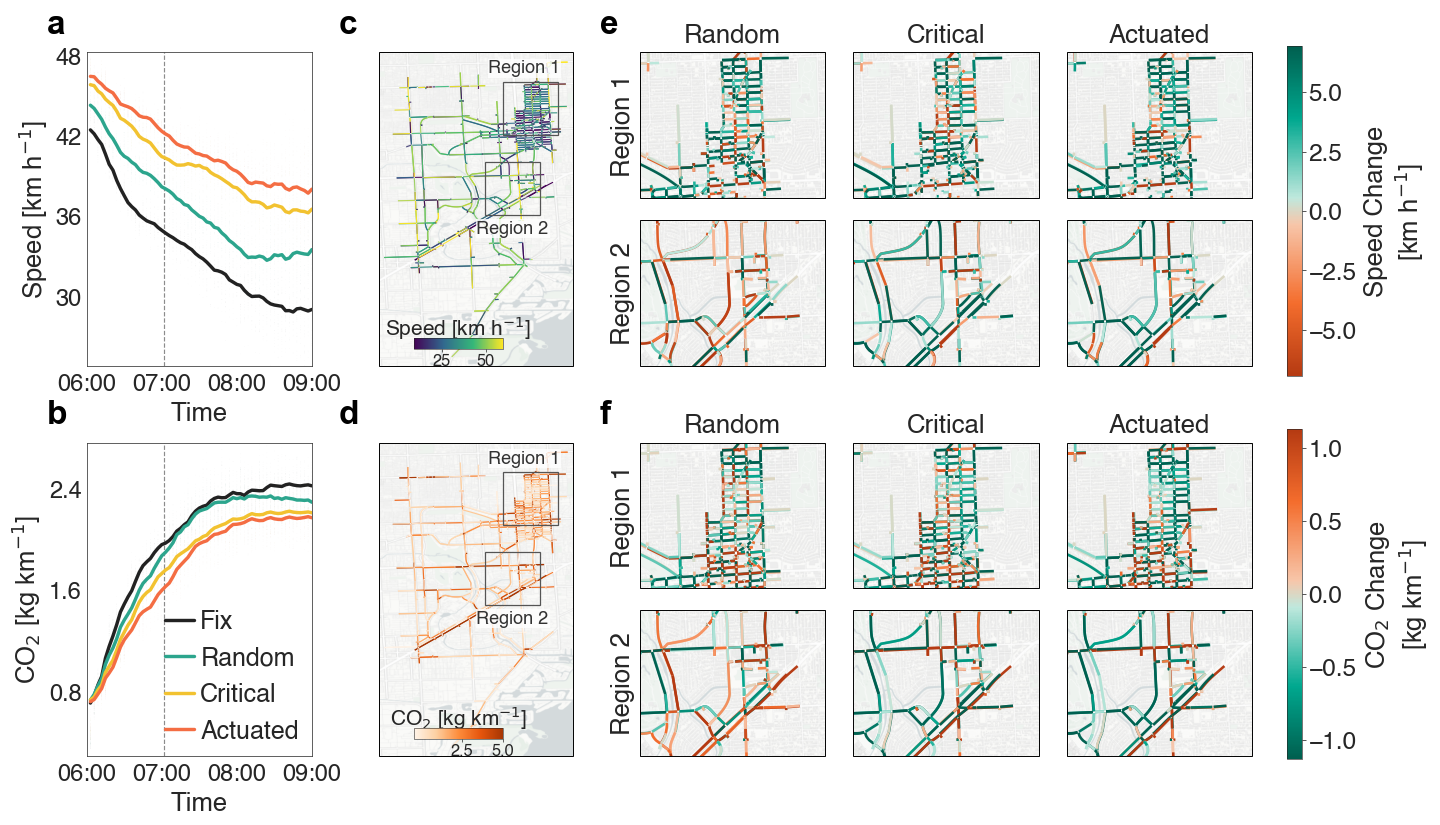

1 extra bytes in post.stringData array


'created' timestamp seems very low; regarding as unix timestamp


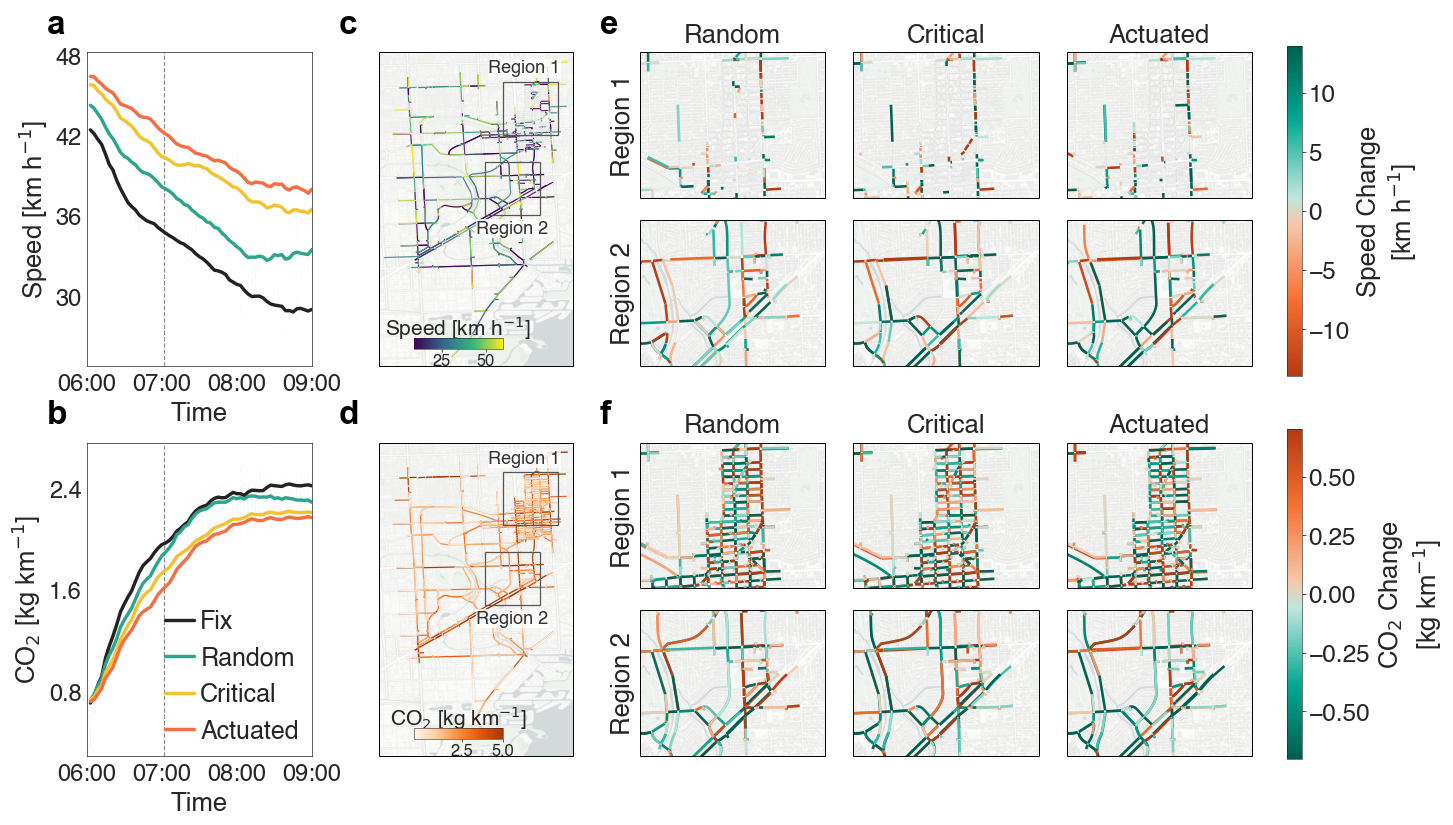

In [7]:
# =========================================================
# 10. Composite main panel for Nature Sustainability style
# =========================================================
import matplotlib.dates as mdates
import matplotlib.ticker as mticker


FIG4_TRAFFIC_COLORS = {
    "Speed": "#1b9e77",
    "Travel time": "#4daf4a",
    "Flow": "#006b5a",
    "Density": "#b8c900",
}
FIG4_EMISSION_COLORS = {
    "CO$_2$": "#d95f02",
    "NO$_x$": "#f46d2d",
    "VOC": "#c98b19",
    "PM": "#8c4b2f",
}
FIG4_SPEED_OVERVIEW_CMAP = LinearSegmentedColormap.from_list(
    "fig4_speed_overview", ["#440154", "#31688e", "#35b779", "#fde725"]
)
FIG4_CO2_OVERVIEW_CMAP = LinearSegmentedColormap.from_list(
    "fig4_co2_overview", ["#fff5eb", "#fdd0a2", "#fd8d3c", "#e6550d", "#a63603"]
)


def load_all_reps(plan_name):
    df = pd.read_parquet(f"../data/processed/{plan_name}_aimsun.parquet")
    return df[df["rep"] != -1].copy()


def set_composite_style():
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "mathtext.fontset": "dejavusans",
        "font.size": 22.5,
        "axes.labelsize": 22.5,
        "axes.titlesize": 25.0,
        "xtick.labelsize": 20.5,
        "ytick.labelsize": 20.5,
        "legend.fontsize": 20.0,
        "axes.linewidth": 0.55,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })


def add_panel_label(fig, label, x, y):
    fig.text(
        x,
        y,
        label,
        fontsize=24.0,
        fontfamily="Arial",
        fontweight="heavy",
        color="black",
        ha="left",
        va="bottom",
        clip_on=False,
    )


def plot_timeseries_composite(
    ax,
    metric_spec,
    methods,
    selected_ent=62,
    ent_step=3,
    smooth_window=7,
    show_ylabel=True,
    legend_ncol=2,
    legend_fontsize=15.0,
    legend_loc="upper left",
    show_legend=True,
):
    method_colors = {
        "Fix": "#222222",
        "Random_0.5": "#2ca58d",
        "Critical_0.5": "#f2c230",
        "Actuated": "#f46d43",
    }

    rep_series = []
    for plan_name, method_title in methods:
        rep_ts = build_rep_ts(
            load_all_reps(plan_name),
            metric_col=metric_spec["col"],
            scale=metric_spec["scale"],
            ent_step=ent_step,
            normalize=False,
        )
        rep_ts["plan"] = plan_name
        rep_ts["method_title"] = method_title
        rep_series.append(rep_ts)

    all_rep_ts = pd.concat(rep_series, ignore_index=True)
    y = all_rep_ts["value"].to_numpy()
    ymin = np.nanpercentile(y, 0.5)
    ymax = np.nanpercentile(y, 99.5)
    ypad = 0.06 * (ymax - ymin) if not np.isclose(ymin, ymax) else 1.0

    for plan_name, method_title in methods:
        color = method_colors.get(plan_name, "#4d4d4d")
        rep_ts = all_rep_ts[all_rep_ts["plan"] == plan_name]

        ax.scatter(
            rep_ts["time"],
            rep_ts["value"],
            s=0.30,
            alpha=0.030,
            color=color,
            edgecolor="none",
            zorder=1,
            rasterized=True,
        )

        trend = (
            rep_ts.groupby("ent")["value"]
                  .mean()
                  .reset_index()
                  .sort_values("ent")
        )
        trend["smooth"] = (
            trend["value"]
            .rolling(window=smooth_window, center=True, min_periods=1)
            .mean()
        )
        trend["time"] = trend["ent"].apply(
            lambda e: pd.Timestamp("2022-01-01 06:00:00")
            + pd.Timedelta(minutes=int(e))
        )

        ax.plot(
            trend["time"],
            trend["smooth"],
            color=color,
            linewidth=2.45,
            label=method_title,
            zorder=3,
        )

    ax.axvline(
        pd.Timestamp("2022-01-01 06:00:00")
        + pd.Timedelta(minutes=int(selected_ent)),
        linestyle="--",
        color="#666666",
        linewidth=0.85,
        alpha=0.75,
        zorder=2,
    )

    ax.set_ylabel(metric_spec.get("ylabel", "") if show_ylabel else "", fontsize=18.5)
    ax.set_xlabel("Time", fontsize=18.5)
    ax.set_xlim([
        pd.Timestamp("2022-01-01 06:00:00"),
        pd.Timestamp("2022-01-01 09:00:00"),
    ])
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune="lower"))
    ax.tick_params(axis="x", rotation=0, length=2.5, width=0.5, pad=3, labelsize=17.0)
    ax.tick_params(axis="y", length=2.5, width=0.5, pad=1, labelsize=17.0)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.55)
        spine.set_color("#333333")

    if show_legend:
        ax.legend(
            loc=legend_loc,
            frameon=False,
            ncol=legend_ncol,
            fontsize=legend_fontsize,
            handlelength=1.15,
            columnspacing=0.45,
            handletextpad=0.25,
            borderaxespad=0.12,
        )

def plot_overview_composite(
    ax,
    selected_ent,
    metric_col,
    scale,
    cmap,
    gamma,
    title,
    colorbar_label,
    q_low=10,
    q_high=90,
    fixed_vmin=None,
    fixed_vmax=None,
    cbar_ticks=None,
):
    total = load_aimsun("Fix", rep=-1)
    gdf = get_metric_gdf(total, selected_ent, metric_col, scale)

    if fixed_vmin is None or fixed_vmax is None:
        vmin, vmax = get_shared_vmin_vmax(
            ["Fix"],
            selected_ent,
            metric_col,
            scale=scale,
            q_low=q_low,
            q_high=q_high,
        )
    else:
        vmin, vmax = fixed_vmin, fixed_vmax

    xmin, ymin, xmax, ymax = gdf.total_bounds
    dx = xmax - xmin
    dy = ymax - ymin
    ax.set_xlim(xmin - 0.03 * dx, xmax + 0.03 * dx)
    ax.set_ylim(ymin - 0.03 * dy, ymax + 0.03 * dy)

    add_safe_basemap(ax)

    gdf.plot(
        ax=ax,
        color="#CFCFCF",
        linewidth=0.20,
        alpha=0.28,
        zorder=2,
    )

    norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax, clip=True)
    gdf.plot(
        ax=ax,
        column="plot_value",
        cmap=cmap,
        linewidth=0.82,
        alpha=0.98,
        norm=norm,
        zorder=4,
        legend=False,
        missing_kwds={"color": "#E6E6E6", "alpha": 0.12},
    )

    for label, bbox in get_core_region_bboxes().items():
        zxmin, zxmax, zymin, zymax = bbox
        ax.add_patch(Rectangle(
            (zxmin, zymin),
            zxmax - zxmin,
            zymax - zymin,
            fill=False,
            edgecolor="#555555",
            linewidth=0.9,
            zorder=20,
            clip_on=False,
        ))
        label_y = zymax + 0.018 * dy if label == "Region 1" else zymin - 0.018 * dy
        label_x = (zxmin + zxmax) / 2 - (0.035 * dx if label == "Region 1" else 0)
        ax.text(
            label_x,
            label_y,
            label,
            fontsize=13.0,
            color="#333333",
            fontweight="bold",
            ha="center",
            va="bottom" if label == "Region 1" else "top",
            zorder=25,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.80, pad=0.7),
        )

    cax = ax.inset_axes([0.18, 0.055, 0.46, 0.034])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = ax.figure.colorbar(sm, cax=cax, orientation="horizontal")
    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)
    cbar.ax.tick_params(labelsize=11.8, length=2.0, width=0.50, pad=1.2)
    cbar.set_label(colorbar_label, fontsize=15.0, labelpad=2.0)
    cbar.ax.xaxis.set_label_position("top")
    cbar.ax.xaxis.set_ticks_position("bottom")
    cbar.outline.set_linewidth(0.4)
    cax.set_facecolor((1, 1, 1, 0.78))

    if title:
        ax.set_title(title, fontsize=22.0, fontweight="bold", pad=2)
    ax.set_axis_off()
    ax.set_aspect(0.64)

    xmin2, xmax2 = ax.get_xlim()
    ymin2, ymax2 = ax.get_ylim()
    ax.add_patch(Rectangle(
        (xmin2, ymin2),
        xmax2 - xmin2,
        ymax2 - ymin2,
        fill=False,
        edgecolor="black",
        linewidth=0.70,
        zorder=30,
        clip_on=False,
    ))


def plot_zoom_composite(
    ax,
    region_name,
    selected_ent,
    method_plan,
    metric_col,
    scale,
    direction,
    cmap,
    vmin,
    vmax,
    method_title=None,
    row_label=None,
):
    gdf = get_diff_gdf(
        method_plan=method_plan,
        ent=selected_ent,
        metric_col=metric_col,
        scale=scale,
        direction=direction,
    )

    bbox = get_core_region_bboxes()[region_name]
    set_bbox_with_fixed_aspect(ax, bbox, target_aspect=0.72)

    add_safe_basemap(ax)

    gdf.plot(
        ax=ax,
        color="#C8C8C8",
        linewidth=0.22,
        alpha=0.48,
        zorder=2,
    )

    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    gdf.plot(
        ax=ax,
        column="plot_value",
        cmap=cmap,
        linewidth=1.85,
        alpha=0.98,
        norm=norm,
        zorder=4,
        legend=False,
        missing_kwds={"color": "#C8C8C8", "alpha": 0.0},
    )

    if method_title is not None:
        ax.set_title(method_title, fontsize=22.0, fontweight="bold", pad=5.0)

    if row_label is not None:
        ax.text(
            -0.026,
            0.5,
            row_label,
            transform=ax.transAxes,
            fontsize=18.5,
            fontweight="normal",
            rotation=90,
            ha="right",
            va="center",
            clip_on=False,
        )

    ax.set_axis_off()
    ax.set_aspect("auto")

    xmin2, xmax2 = ax.get_xlim()
    ymin2, ymax2 = ax.get_ylim()
    ax.add_patch(Rectangle(
        (xmin2, ymin2),
        xmax2 - xmin2,
        ymax2 - ymin2,
        fill=False,
        edgecolor="black",
        linewidth=0.70,
        zorder=20,
        clip_on=False,
    ))


def add_vertical_colorbar(fig, cax, cmap, norm, label):
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, cax=cax, orientation="vertical")
    cbar.ax.yaxis.set_ticks_position("right")
    cbar.ax.yaxis.set_label_position("right")
    cbar.ax.tick_params(labelsize=17.5, length=3, width=0.55, pad=2)
    cbar.set_label(label, fontsize=18.5, labelpad=5.0, rotation=90)
    cbar.outline.set_linewidth(0.45)
    return cbar


def generate_nature_sustainability_main_panel(
    save_pdf="../figure/fig4_panel.pdf",
    save_png="../figure/fig4_panel.png",
    method_suffix="0.5",
    map_selected_ent="original",
    timeseries_selected_ent=62,
):
    set_composite_style()
    os.makedirs(os.path.dirname(save_pdf), exist_ok=True)
    if map_selected_ent == "original":
        overview_ent = 62
        speed_ent_by_region = {"Region 1": 57, "Region 2": 62}
        co2_ent_by_region = {"Region 1": 62, "Region 2": 62}
    else:
        if map_selected_ent is None:
            map_selected_ent = int(load_aimsun("Fix", rep=-1)["ent"].max())
        overview_ent = map_selected_ent
        speed_ent_by_region = {"Region 1": map_selected_ent, "Region 2": map_selected_ent}
        co2_ent_by_region = {"Region 1": map_selected_ent, "Region 2": map_selected_ent}


    traffic_metrics = {
        "Speed": {"col": "speed", "scale": 1.0, "ylabel": "Speed [km h$^{-1}$]"},
        "Travel time": {"col": "ttime", "scale": 1.0},
        "Flow": {"col": "flow", "scale": 1.0},
        "Density": {"col": "density", "scale": 1.0},
    }
    emission_metrics = {
        "CO$_2$": {"col": "CO2_interurban", "scale": 1 / 1000, "ylabel": "CO$_2$ [kg km$^{-1}$]"},
        "NO$_x$": {"col": "NOx_interurban", "scale": 1.0},
        "VOC": {"col": "VOC_interurban", "scale": 1.0},
        "PM": {"col": "PM_interurban", "scale": 1.0},
    }

    random_plan = f"Random_{method_suffix}"
    critical_plan = f"Critical_{method_suffix}"
    timeseries_methods = [
        ("Fix", "Fix"),
        (random_plan, "Random"),
        (critical_plan, "Critical"),
        ("Actuated", "Actuated"),
    ]
    methods = [
        (random_plan, "Random"),
        (critical_plan, "Critical"),
        ("Actuated", "Actuated"),
    ]
    regions = [("Region 1", "Region 1"), ("Region 2", "Region 2")]
    method_plans = [m[0] for m in methods]
    region_names = [r[0] for r in regions]

    speed_vmin, speed_vmax = get_shared_diff_range(
        method_plans,
        region_names,
        speed_ent_by_region,
        "speed",
        scale=1.0,
        direction="method_minus_fix",
        q=65,
    )
    co2_vmin, co2_vmax = get_shared_diff_range(
        method_plans,
        region_names,
        co2_ent_by_region,
        "CO2_interurban",
        scale=1 / 1000,
        direction="method_minus_fix",
        q=65,
    )

    speed_cmap = get_soft_diverging_cmap("speed")
    co2_cmap = get_soft_diverging_cmap("co2")
    speed_norm = TwoSlopeNorm(vmin=speed_vmin, vcenter=0, vmax=speed_vmax)
    co2_norm = TwoSlopeNorm(vmin=co2_vmin, vcenter=0, vmax=co2_vmax)

    fig = plt.figure(figsize=(13.35, 8.15))
    gs = fig.add_gridspec(
        nrows=2,
        ncols=3,
        height_ratios=[1.0, 1.0],
        width_ratios=[1.60, 1.96, 4.35],
        left=0.045,
        right=0.918,
        bottom=0.082,
        top=0.945,
        wspace=0.070,
        hspace=0.245,
    )

    ax_ts_traffic = fig.add_subplot(gs[0, 0])
    ax_ts_emission = fig.add_subplot(gs[1, 0])
    plot_timeseries_composite(
        ax_ts_traffic,
        traffic_metrics["Speed"],
        timeseries_methods,
        selected_ent=timeseries_selected_ent,
        legend_ncol=2,
        legend_fontsize=18.0,
        show_legend=False,
    )
    plot_timeseries_composite(
        ax_ts_emission,
        emission_metrics["CO$_2$"],
        timeseries_methods,
        selected_ent=timeseries_selected_ent,
        legend_ncol=1,
        legend_fontsize=18.0,
        legend_loc="lower right",
    )

    ax_over_speed = fig.add_subplot(gs[0, 1])
    ax_over_co2 = fig.add_subplot(gs[1, 1])
    plot_overview_composite(
        ax_over_speed,
        selected_ent=overview_ent,
        metric_col="speed",
        scale=1.0,
        cmap=FIG4_SPEED_OVERVIEW_CMAP,
        gamma=0.95,
        title="",
        colorbar_label="Speed [km h$^{-1}$]",
        fixed_vmin=10,
        fixed_vmax=60,
        cbar_ticks=[25, 50],
    )
    plot_overview_composite(
        ax_over_co2,
        selected_ent=overview_ent,
        metric_col="CO2_interurban",
        scale=1 / 1000,
        cmap=FIG4_CO2_OVERVIEW_CMAP,
        gamma=0.90,
        title="",
        colorbar_label="CO$_2$ [kg km$^{-1}$]",
        fixed_vmin=0,
        fixed_vmax=5,
        cbar_ticks=[2.5, 5.0],
    )

    speed_block = gs[0, 2].subgridspec(
        2,
        3,
        wspace=0.150,
        hspace=0.150,
    )
    co2_block = gs[1, 2].subgridspec(
        2,
        3,
        wspace=0.150,
        hspace=0.150,
    )

    speed_axes = []
    co2_axes = []
    for i, (region_name, region_short) in enumerate(regions):
        for j, (method_plan, method_title) in enumerate(methods):
            ax = fig.add_subplot(speed_block[i, j])
            plot_zoom_composite(
                ax,
                region_name=region_name,
                selected_ent=speed_ent_by_region[region_name],
                method_plan=method_plan,
                metric_col="speed",
                scale=1.0,
                direction="method_minus_fix",
                cmap=speed_cmap,
                vmin=speed_vmin,
                vmax=speed_vmax,
                method_title=None,
                row_label=region_short if j == 0 else None,
            )
            speed_axes.append(ax)

    for i, (region_name, region_short) in enumerate(regions):
        for j, (method_plan, method_title) in enumerate(methods):
            ax = fig.add_subplot(co2_block[i, j])
            plot_zoom_composite(
                ax,
                region_name=region_name,
                selected_ent=co2_ent_by_region[region_name],
                method_plan=method_plan,
                metric_col="CO2_interurban",
                scale=1 / 1000,
                direction="method_minus_fix",
                cmap=co2_cmap,
                vmin=co2_vmin,
                vmax=co2_vmax,
                method_title=None,
                row_label=region_short if j == 0 else None,
            )
            co2_axes.append(ax)

    cax_speed = fig.add_axes([0.944, 0.548, 0.011, 0.405])
    cax_co2 = fig.add_axes([0.944, 0.078, 0.011, 0.405])
    add_vertical_colorbar(
        fig,
        cax_speed,
        speed_cmap,
        speed_norm,
        "Speed Change\n[km h$^{-1}$]",
    )
    add_vertical_colorbar(
        fig,
        cax_co2,
        co2_cmap,
        co2_norm,
        "CO$_2$ Change\n[kg km$^{-1}$]",
    )

    speed_boxes = [ax.get_position() for ax in speed_axes]
    co2_boxes = [ax.get_position() for ax in co2_axes]
    speed_x0 = min(b.x0 for b in speed_boxes)
    speed_y1 = max(b.y1 for b in speed_boxes)
    co2_x0 = min(b.x0 for b in co2_boxes)
    co2_y1 = max(b.y1 for b in co2_boxes)

    for j, (_, method_title) in enumerate(methods):
        box = speed_axes[j].get_position()
        fig.text((box.x0 + box.x1) / 2, speed_y1 + 0.007, method_title, fontsize=18.5, ha="center", va="bottom")
        box = co2_axes[j].get_position()
        fig.text((box.x0 + box.x1) / 2, co2_y1 + 0.007, method_title, fontsize=18.5, ha="center", va="bottom")

    ts_traffic_box = ax_ts_traffic.get_position()
    ts_emission_box = ax_ts_emission.get_position()
    over_speed_box = ax_over_speed.get_position()
    over_co2_box = ax_over_co2.get_position()

    label_top_y = max(ts_traffic_box.y1, over_speed_box.y1, speed_y1) + 0.015
    label_bottom_y = max(ts_emission_box.y1, over_co2_box.y1, co2_y1) + 0.015
    add_panel_label(fig, "a", ts_traffic_box.x0 - 0.030, label_top_y)
    add_panel_label(fig, "c", over_speed_box.x0 - 0.030, label_top_y)
    add_panel_label(fig, "e", speed_x0 - 0.030, label_top_y)
    add_panel_label(fig, "b", ts_emission_box.x0 - 0.030, label_bottom_y)
    add_panel_label(fig, "d", over_co2_box.x0 - 0.030, label_bottom_y)
    add_panel_label(fig, "f", co2_x0 - 0.030, label_bottom_y)

    fig.savefig(save_pdf, dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(save_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

generate_nature_sustainability_main_panel()

generate_nature_sustainability_main_panel(
    save_pdf="../figure/fig4_panel_30pct_lastslot.pdf",
    save_png="../figure/fig4_panel_30pct_lastslot.png",
    method_suffix="0.5",
    map_selected_ent=None,
    timeseries_selected_ent=62,
)
